In [71]:
import numpy as np

from TimeSeriesGeneratorV2 import EventTimestampGenerator, EventSampleSpace, TimeSeriesGenerator

In [72]:
N = 3
cycles = 2
time_intervals = [(i, i+1) for i in range(N)]
occurrences = [i+1 for i in range(N)]
noise_sds = [0.5]*N
no_occurrences_sds = [0.5]*N

print("Time intervals:", time_intervals)
print("Occurrences:", occurrences)
print("Period standard deviations:", noise_sds)
print("Number of occurrences standard deviations:", no_occurrences_sds)

Time intervals: [(0, 1), (1, 2), (2, 3)]
Occurrences: [1, 2, 3]
Period standard deviations: [0.5, 0.5, 0.5]
Number of occurrences standard deviations: [0.5, 0.5, 0.5]


In [73]:
class ExampleETG(EventTimestampGenerator):
    """Class representing the frequency of events over time, defined by occurrences and time intervals"""
    def __init__(self, occurrences, time_intervals, noise_sds, occurrences_sds):
        self.noise_sds = noise_sds
        self.occurrences_sds = occurrences_sds
        super().__init__(occurrences, time_intervals)
        
        
    def sample_noise (self, i):
        """Samples a timing interval"""
        return np.random.normal(loc=0, scale=self.noise_sds[i])
    
    def sample_occurrences(self, occurrences_i, i):
        sample = int(np.round(np.random.normal(loc=occurrences_i, scale=self.occurrences_sds[i])))
        return sample if sample >= 0 else 0


class ExampleSampleSpace(EventSampleSpace):
    def __init__(self):
        super().__init__()
    
    def sample(self, t):
        return np.random.normal(loc=1, scale=1)

In [74]:
etg = ExampleETG(occurrences, time_intervals, noise_sds, no_occurrences_sds)
ess = ExampleSampleSpace()

In [75]:
def on_event(event):
    print(f"event: {event}")
    print("--------")

time_series_generator = TimeSeriesGenerator([(etg, ess)], on_event)
data = time_series_generator.run(cycles*N)
print("Generated data:", data)

event: (-0.08258655355521749, 1.085386928252229)
--------
event: (1.9894176777925978, 2.318652477708641)
--------
event: (2.5195048285410775, 0.4038087932491109)
--------
event: (1.5321827820998948, 1.472476477587442)
--------
event: (1.4585840736632356, -0.5044667998757832)
--------
event: (1.5227699351141641, 0.6112484116997507)
--------
event: (1.3915221138236176, 1.5374467408579702)
--------
event: (3.8183541469071134, 2.2497492994853774)
--------
event: (4.502724687140277, 0.6673079593117712)
--------
event: (4.48135806320216, -0.3517400302592508)
--------
event: (4.702528516260498, 1.6755104991297625)
--------
event: (4.9236184385403, 1.3669253350474095)
--------
event: (5.009075130810924, 0.7043560610268738)
--------
event: (5.132673428274851, 1.4159493361469124)
--------
Generated data: [(-0.08258655355521749, 1.085386928252229), (1.9894176777925978, 2.318652477708641), (2.5195048285410775, 0.4038087932491109), (1.5321827820998948, 1.472476477587442), (1.4585840736632356, -0.50

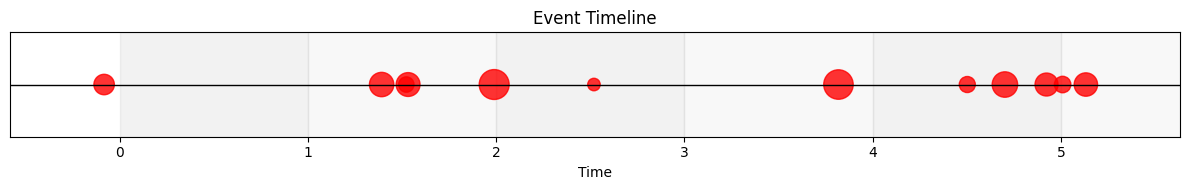

In [76]:
from Analytics import plot_timeline, extend_intervals
plot_timeline(data, extend_intervals(time_intervals, cycles))


In [77]:
from Analytics import count_number_of_occurrences_in_intervals
count_number_of_occurrences_in_intervals(time_intervals, data)

[0, 5, 1]